## AGN Homework 4 – Photometric Reverberation Mapping

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl

import matplotlib.pyplot as plt

import photRM

from pyzdcf import pyzdcf
from lc_proc import lc_proc

from astroquery.vizier import Vizier
from astroquery.sdss import SDSS

from astropy import units as u
from astropy import coordinates as coords

import speclite.filters

%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

In [2]:
print(photRM.__doc__)


Module name: photRM

Authors: Isidora Jankov & Dr. Andjelka Kovačević

Contact: ijankov@proton.me
------------------------------------------------

Description:
------------
A set of functions for:

- generating artificial AGN light curves using a method based on the Damped 
  Random Walk process where real physical AGN quantities are taken into account 
  (see Kovačević et al. 2021).
- generating artificial AGN photometric light curves for testing photometric 
  reverberation mapping methods (see Jankov et al. 2022).
- implementation of photometric reverberation mapping formalism described in 
  Chelouche & Daniel (2012)
- utility functions for preparing these light curves for pyZDCF 
  (Jankov et al., in prep), ZDCF and PLIKE programs (Alexander 1997).
  
Python functions for generating artificial light curves (lc_conti, lc_response,
lc_merged), as well as filters_viz() are adapted from original python code 
written by Dr. Andjelka Kovačević. There were several improvements introduc

## 1. Synthetic Lightcurves

### a)

In [3]:
print(photRM.lc_two_bands.__doc__)


    Generate two artificial light curves: 
        
        - one in the hypothetical X band covering solely the continuum emission;
        - one in the hypothetical Y band covering some emission line and its
          surrounding continuum;
    
    The X band light curve is generated using a stochastic model based on the 
    Damped random walk (DRW) proccess (see lc_conti() docs). The Y band light
    curve is modeled using a method described in Jankov et al. (2022) which is 
    based on the photoRM formalism by Chelouche & Daniel (2012).

    Parameters
    ----------
    T: int
        Total time span of the light curve. It is recommended to generate light
        curves to be at least 10 times longer than their characteristic 
        timescale (Kozłowski 2017). 
    osc: bool, default=True
        If True, light curve simulation will take an oscillatory signal into 
        account.
    A: float, default=0.14
        Amplitude of the oscillatory signal in magnitudes (used onl

#### Task:

- generate three pairs of continuum and emission line lightcurves
- plot and compare resulting parameters and simulation data

#### Result:

Properties of the simulated AGN object:
---------------------------------------
log(L) = 43.00
MBH = 3.14e+06 M_sun
tau_DRW = 17.31 days
sigma_DRW = 0.05 mag^2/day
Time-lag = 9.86 days

Properties of the simulated AGN object:
---------------------------------------
log(L) = 44.00
MBH = 1.46e+07 M_sun
tau_DRW = 31.98 days
sigma_DRW = 0.03 mag^2/day
Time-lag = 33.65 days

Properties of the simulated AGN object:
---------------------------------------
log(L) = 45.00
MBH = 6.76e+07 M_sun
tau_DRW = 59.10 days
sigma_DRW = 0.01 mag^2/day
Time-lag = 114.82 days



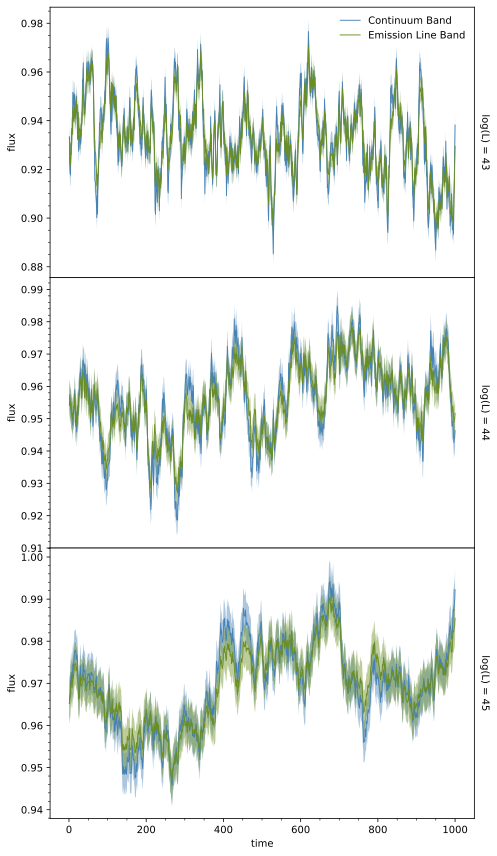

In [4]:
x_band_43, y_band_43, line_response_43 = photRM.lc_two_bands(T = 5000, z = 0.1, lum = 43, wl = 0.25, wc = 0.75)
print()
x_band_44, y_band_44, line_response_44 = photRM.lc_two_bands(T = 5000, z = 0.1, lum = 44, wl = 0.25, wc = 0.75)
print()
x_band_45, y_band_45, line_response_45 = photRM.lc_two_bands(T = 5000, z = 0.1, lum = 45, wl = 0.25, wc = 0.75)
print()

fig, axs = plt.subplots(3, 1, figsize=[7, 12], sharex=True, layout='tight', gridspec_kw={'hspace': 0})

axs[0].fill_between(x_band_43['t'][:1000],
                    x_band_43['flux'][:1000] - x_band_43['err'][:1000],
                    x_band_43['flux'][:1000] + x_band_43['err'][:1000],
                    fc='steelblue', ec='none', alpha=0.45)
axs[0].plot(x_band_43['t'][:1000], x_band_43['flux'][:1000], c='steelblue', lw=0.9, label='Continuum Band')
axs[0].fill_between(y_band_43['t'][:1000],
                    y_band_43['flux'][:1000] - y_band_43['err'][:1000],
                    y_band_43['flux'][:1000] + y_band_43['err'][:1000],
                    fc='olivedrab', ec='none', alpha=0.45)
axs[0].plot(y_band_43['t'][:1000], y_band_43['flux'][:1000], c='olivedrab', lw=0.9, label='Emission Line Band')
axs[0].annotate('log(L) = 43', xy=(1.025, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[0].set_ylabel('flux')
axs[0].legend()

axs[1].fill_between(x_band_44['t'][:1000],
                    x_band_44['flux'][:1000] - x_band_44['err'][:1000],
                    x_band_44['flux'][:1000] + x_band_44['err'][:1000],
                    fc='steelblue', ec='none', alpha=0.45)
axs[1].plot(x_band_44['t'][:1000], x_band_44['flux'][:1000], c='steelblue', lw=0.9)
axs[1].fill_between(y_band_44['t'][:1000],
                    y_band_44['flux'][:1000] - y_band_44['err'][:1000],
                    y_band_44['flux'][:1000] + y_band_44['err'][:1000],
                    fc='olivedrab', ec='none', alpha=0.45)
axs[1].plot(y_band_44['t'][:1000], y_band_44['flux'][:1000], c='olivedrab', lw=0.9)
axs[1].annotate('log(L) = 44', xy=(1.025, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[1].set_ylabel('flux')

axs[2].fill_between(x_band_45['t'][:1000],
                    x_band_45['flux'][:1000] - x_band_45['err'][:1000],
                    x_band_45['flux'][:1000] + x_band_45['err'][:1000],
                    fc='steelblue', ec='none', alpha=0.45)
axs[2].plot(x_band_45['t'][:1000], x_band_45['flux'][:1000], c='steelblue', lw=0.9)
axs[2].fill_between(y_band_45['t'][:1000],
                    y_band_45['flux'][:1000] - y_band_45['err'][:1000],
                    y_band_45['flux'][:1000] + y_band_45['err'][:1000],
                    fc='olivedrab', ec='none', alpha=0.45)
axs[2].plot(y_band_45['t'][:1000], y_band_45['flux'][:1000], c='olivedrab', lw=0.9)
axs[2].annotate('log(L) = 45', xy=(1.025, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[2].set_ylabel('flux')
axs[2].set_xlabel('time')

plt.show()
plt.close()

with open('data/x_band_43.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(x_band_43['t'][:1000], x_band_43['flux'][:1000], x_band_43['err'][:1000]):
        f.write(templ.format(*line))
with open('data/y_band_43.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(y_band_43['t'][:1000], y_band_43['flux'][:1000], y_band_43['err'][:1000]):
        f.write(templ.format(*line))
with open('data/line_response_43.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(line_response_43['t'][:1000], line_response_43['flux'][:1000], line_response_43['err'][:1000]):
        f.write(templ.format(*line))

with open('data/x_band_44.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(x_band_44['t'][:1000], x_band_44['flux'][:1000], x_band_44['err'][:1000]):
        f.write(templ.format(*line))
with open('data/y_band_44.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(y_band_44['t'][:1000], y_band_44['flux'][:1000], y_band_44['err'][:1000]):
        f.write(templ.format(*line))
with open('data/line_response_44.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(line_response_44['t'][:1000], line_response_44['flux'][:1000], line_response_44['err'][:1000]):
        f.write(templ.format(*line))

with open('data/x_band_45.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(x_band_45['t'][:1000], x_band_45['flux'][:1000], x_band_45['err'][:1000]):
        f.write(templ.format(*line))
with open('data/y_band_45.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(y_band_45['t'][:1000], y_band_45['flux'][:1000], y_band_45['err'][:1000]):
        f.write(templ.format(*line))
with open('data/line_response_45.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(line_response_45['t'][:1000], line_response_45['flux'][:1000], line_response_45['err'][:1000]):
        f.write(templ.format(*line))

#### Explanation:

- larger time lags for higher luminosity
- broad line region pushed further from central engine by intense radiation

### b)

#### Task:

- estimate time lag
- plot results

#### Result:

In [5]:
par_dict = {
    'autocf': True,
    'prefix': 'acf_43',
    'uniform_sampling': False,
    'omit_zero_lags': True,
    'minpts': 0,
    'num_MC': 100,
    'lc1_name': 'x_band_43.txt'
}

acf_43 = pyzdcf('./data/', './results/', intr=False, parameters=par_dict, sep=' ', sparse='auto')

par_dict = {
    'autocf': False,
    'prefix': 'ccf_43',
    'uniform_sampling': False,
    'omit_zero_lags': True,
    'minpts': 0,
    'num_MC': 100,
    'lc1_name': 'x_band_43.txt',
    'lc2_name': 'y_band_43.txt',
}

ccf_43 = pyzdcf('./data/', './results/', intr=False, parameters=par_dict, sep=' ', sparse='auto')

par_dict = {
    'autocf': True,
    'prefix': 'acf_44',
    'uniform_sampling': False,
    'omit_zero_lags': True,
    'minpts': 0,
    'num_MC': 100,
    'lc1_name': 'x_band_44.txt'
}

acf_44 = pyzdcf('./data/', './results/', intr=False, parameters=par_dict, sep=' ', sparse='auto')

par_dict = {
    'autocf': False,
    'prefix': 'ccf_44',
    'uniform_sampling': False,
    'omit_zero_lags': True,
    'minpts': 0,
    'num_MC': 100,
    'lc1_name': 'x_band_44.txt',
    'lc2_name': 'y_band_44.txt',
}

ccf_44 = pyzdcf('./data/', './results/', intr=False, parameters=par_dict, sep=' ', sparse='auto')

par_dict = {
    'autocf': True,
    'prefix': 'acf_45',
    'uniform_sampling': False,
    'omit_zero_lags': True,
    'minpts': 0,
    'num_MC': 100,
    'lc1_name': 'x_band_45.txt'
}

acf_45 = pyzdcf('./data/', './results/', intr=False, parameters=par_dict, sep=' ', sparse='auto')

par_dict = {
    'autocf': False,
    'prefix': 'ccf_45',
    'uniform_sampling': False,
    'omit_zero_lags': True,
    'minpts': 0,
    'num_MC': 100,
    'lc1_name': 'x_band_45.txt',
    'lc2_name': 'y_band_45.txt',
}

ccf_45 = pyzdcf('./data/', './results/', intr=False, parameters=par_dict, sep=' ', sparse='auto')


pyZDCF begins:

pyZDCF PARAMETERS:

Autocorrelation?   True
Uniform sampling?  False
Omit zero lags?    True
Minimal # in bin:  11
# of Monte Carlo:  100
Monte Carlo seed:  123456

Binning with minimum of 11 points per bin and resolution of 0.001

990 bins actually used, 45.0 inter-dependent pairs discarded.


acf_43.dcf written...

pyZDCF ended.


pyZDCF begins:

pyZDCF PARAMETERS:

Autocorrelation?   False
Uniform sampling?  False
Omit zero lags?    True
Minimal # in bin:  11
# of Monte Carlo:  100
Monte Carlo seed:  123456

Binning with minimum of 11 points per bin and resolution of 0.001

992 bins actually used, 500032 inter-dependent pairs discarded.


ccf_43.dcf written...

pyZDCF ended.


pyZDCF begins:

pyZDCF PARAMETERS:

Autocorrelation?   True
Uniform sampling?  False
Omit zero lags?    True
Minimal # in bin:  11
# of Monte Carlo:  100
Monte Carlo seed:  123456

Binning with minimum of 11 points per bin and resolution of 0.001

990 bins actually used, 45.0 inter-dependent p

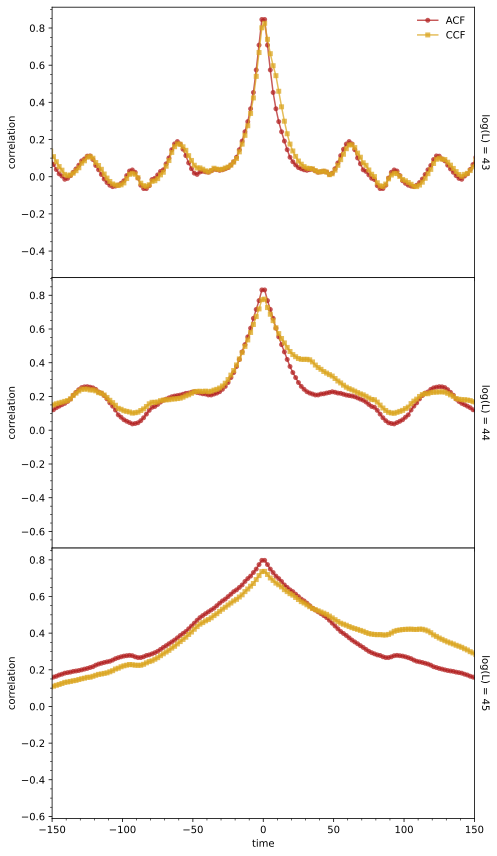

In [6]:
acf_43 = photRM.add_inverted_acf(acf_43)
acf_44 = photRM.add_inverted_acf(acf_44)
acf_45 = photRM.add_inverted_acf(acf_45)

acf_43 = acf_43.drop_duplicates(subset=['tau']).sort_values('tau')
acf_44 = acf_44.drop_duplicates(subset=['tau']).sort_values('tau')
acf_45 = acf_45.drop_duplicates(subset=['tau']).sort_values('tau')

acf_43 = photRM.interp(ccf_43, acf_43)
acf_44 = photRM.interp(ccf_44, acf_44)
acf_45 = photRM.interp(ccf_45, acf_45)

fig, axs = plt.subplots(3, 1, figsize=[7, 12], sharex=True, layout='tight', gridspec_kw={'hspace': 0})

axs[0].plot(acf_43['tau'], acf_43['dcf'], 'o-', c='firebrick', mec='none', ms=5, alpha=0.75, label='ACF')
axs[0].plot(ccf_43['tau'], ccf_43['dcf'], 's-', c='goldenrod', mec='none', ms=5, alpha=0.75, label='CCF')
axs[0].annotate('log(L) = 43', xy=(1.025, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[0].set_ylabel('correlation')
axs[0].set_xlim(-150, 150)
axs[0].legend()

axs[1].plot(acf_44['tau'], acf_44['dcf'], 'o-', c='firebrick', mec='none', ms=5, alpha=0.75)
axs[1].plot(ccf_44['tau'], ccf_44['dcf'], 's-', c='goldenrod', mec='none', ms=5, alpha=0.75)
axs[1].annotate('log(L) = 44', xy=(1.025, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[1].set_ylabel('correlation')
axs[1].set_xlim(-150, 150)

axs[2].plot(acf_45['tau'], acf_45['dcf'], 'o-', c='firebrick', mec='none', ms=5, alpha=0.75)
axs[2].plot(ccf_45['tau'], ccf_45['dcf'], 's-', c='goldenrod', mec='none', ms=5, alpha=0.75)
axs[2].annotate('log(L) = 45', xy=(1.025, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[2].set_ylabel('correlation')
axs[2].set_xlabel('time')
axs[2].set_xlim(-150, 150)

plt.show()
plt.close()

In [7]:
print(photRM.peak_finder.__doc__)


    Find highest positive peak in a user defined interval. Useful for finding
    coresponding time-lag in CCF. By setting first=True, you can also specify 
    that you want to select first peak found in a given interval, instead of 
    the highest one.
    


Peak candidates (x-axis vals):  [ 9. 43.]
Max. peak:  9.0
Peak candidates (x-axis vals):  [33. 93.]
Max. peak:  33.0
Peak candidates (x-axis vals):  [115.]
Max. peak:  115.0


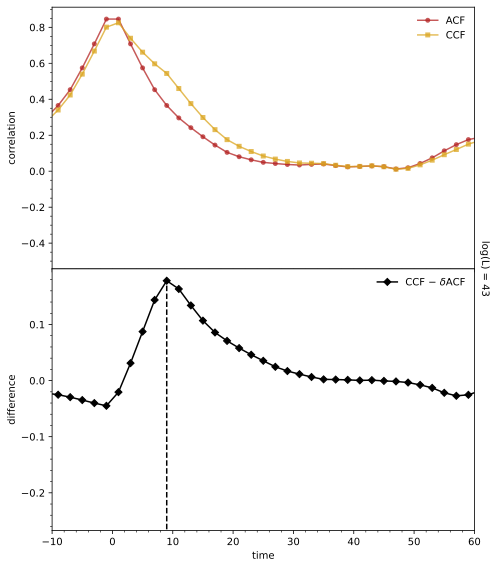

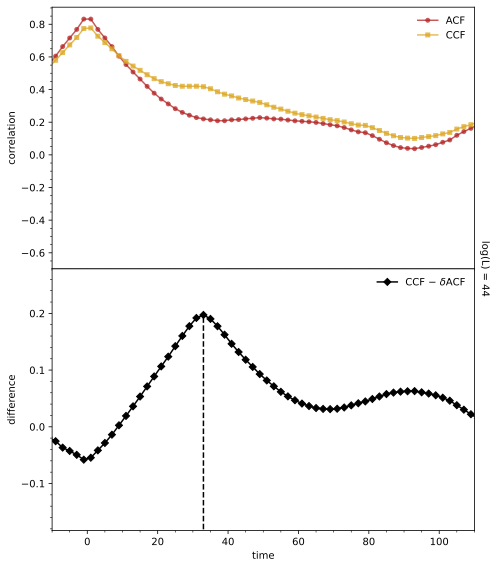

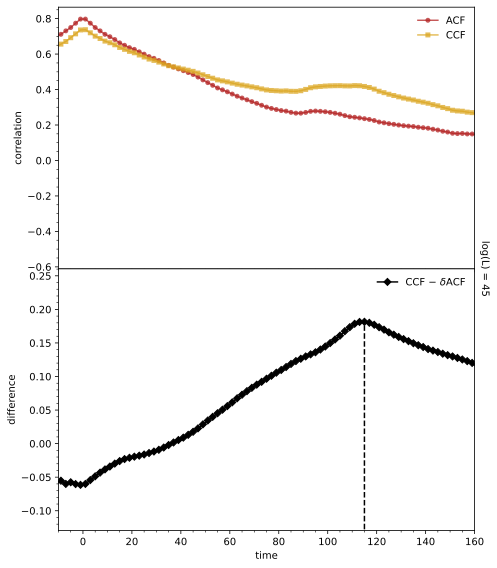

In [8]:
diff_43 = photRM.delta_ccf(acf_43, ccf_43)
diff_44 = photRM.delta_ccf(acf_44, ccf_44)
diff_45 = photRM.delta_ccf(acf_45, ccf_45)

tau_43, peaks_x_43, peaks_y_43 = photRM.peak_finder(diff_43.dcf.values, diff_43.tau.values, (0,50))
tau_44, peaks_x_44, peaks_y_44 = photRM.peak_finder(diff_44.dcf.values, diff_44.tau.values, (0,100))
tau_45, peaks_x_45, peaks_y_45 = photRM.peak_finder(diff_45.dcf.values, diff_45.tau.values, (0,150))

fig, axs = plt.subplots(2, 1, figsize=[7, 8], sharex=True, layout='tight', gridspec_kw={'hspace': 0})

axs[0].plot(acf_43['tau'], acf_43['dcf'], 'o-', c='firebrick', mec='none', ms=5, alpha=0.75, label='ACF')
axs[0].plot(ccf_43['tau'], ccf_43['dcf'], 's-', c='goldenrod', mec='none', ms=5, alpha=0.75, label='CCF')
axs[0].annotate('log(L) = 43', xy=(1.025, 0), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[0].set_ylabel('correlation')
axs[0].set_xlim(-10, 60)
axs[0].legend()

axs[1].plot(diff_43['tau'], diff_43['dcf'], 'D-k', ms=5, label=r'CCF $-$ $\delta$ACF')
axs[1].set_ylabel('difference')
axs[1].set_xlabel('time')
axs[1].set_ylim(axs[1].set_ylim())
axs[1].vlines(peaks_x_43[np.argmax(peaks_y_43)], -100, peaks_y_43[np.argmax(peaks_y_43)], ls='--', color='k')
axs[1].set_xlim(-10, 60)
axs[1].legend()

plt.show()
plt.close()

fig, axs = plt.subplots(2, 1, figsize=[7, 8], sharex=True, layout='tight', gridspec_kw={'hspace': 0})

axs[0].plot(acf_44['tau'], acf_44['dcf'], 'o-', c='firebrick', mec='none', ms=5, alpha=0.75, label='ACF')
axs[0].plot(ccf_44['tau'], ccf_44['dcf'], 's-', c='goldenrod', mec='none', ms=5, alpha=0.75, label='CCF')
axs[0].annotate('log(L) = 44', xy=(1.025, 0), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[0].set_ylabel('correlation')
axs[0].set_xlim(-10, 110)
axs[0].legend()

axs[1].plot(diff_44['tau'], diff_44['dcf'], 'D-k', ms=5, label=r'CCF $-$ $\delta$ACF')
axs[1].set_ylabel('difference')
axs[1].set_xlabel('time')
axs[1].set_ylim(axs[1].set_ylim())
axs[1].vlines(peaks_x_44[np.argmax(peaks_y_44)], -100, peaks_y_44[np.argmax(peaks_y_44)], ls='--', color='k')
axs[1].set_xlim(-10, 110)
axs[1].legend()

plt.show()
plt.close

fig, axs = plt.subplots(2, 1, figsize=[7, 8], sharex=True, layout='tight', gridspec_kw={'hspace': 0})

axs[0].plot(acf_45['tau'], acf_45['dcf'], 'o-', c='firebrick', mec='none', ms=5, alpha=0.75, label='ACF')
axs[0].plot(ccf_45['tau'], ccf_45['dcf'], 's-', c='goldenrod', mec='none', ms=5, alpha=0.75, label='CCF')
axs[0].annotate('log(L) = 45', xy=(1.025, 0), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[0].set_ylabel('correlation')
axs[0].set_xlim(-10, 160)
axs[0].legend()

axs[1].plot(diff_45['tau'], diff_45['dcf'], 'D-k', ms=5, label=r'CCF $-$ $\delta$ACF')
axs[1].set_ylabel('difference')
axs[1].set_xlabel('time')
axs[1].set_ylim(axs[1].set_ylim())
axs[1].vlines(peaks_x_45[np.argmax(peaks_y_45)], -100, peaks_y_45[np.argmax(peaks_y_45)], ls='--', color='k')
axs[1].set_xlim(-10, 160)
axs[1].legend()

plt.show()
plt.close()

#### Comparison:

- actual and recovered values are comparable

### c)

#### Task:

- investigate gap impact

#### Result:

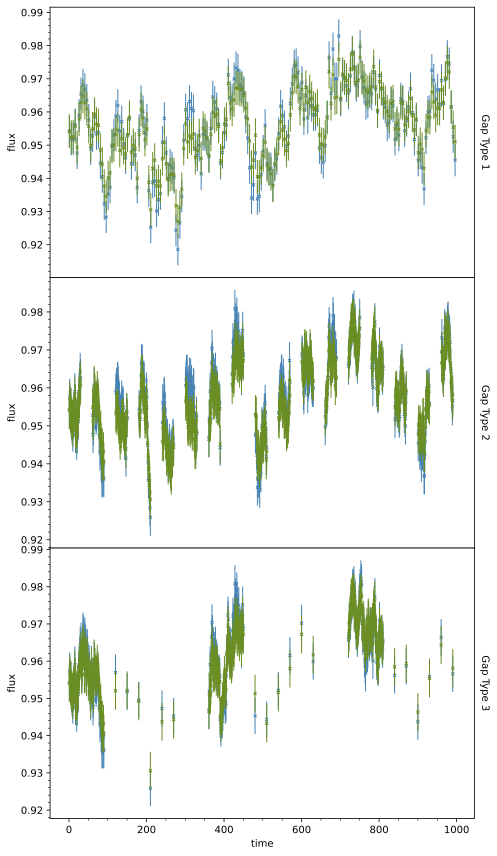

In [9]:
mask_1 = ([True] + [False] * 4) * 200
mask_2 = (([True] * 30 + [False] * 30) * 20)[:1000]
mask_3 = (([True] * 90 + ([False] * 29 + [True]) * 6 + [False] * 90) * 3)[:1000]

x_band_44_gap_1 = {}
x_band_44_gap_1['t'] = np.array(x_band_44['t'][:1000])[mask_1]
x_band_44_gap_1['flux'] = np.array(x_band_44['flux'][:1000])[mask_1]
x_band_44_gap_1['err'] = np.array(x_band_44['err'][:1000])[mask_1]

y_band_44_gap_1 = {}
y_band_44_gap_1['t'] = np.array(y_band_44['t'][:1000])[mask_1]
y_band_44_gap_1['flux'] = np.array(y_band_44['flux'][:1000])[mask_1]
y_band_44_gap_1['err'] = np.array(y_band_44['err'][:1000])[mask_1]

line_response_44_gap_1 = {}
line_response_44_gap_1['t'] = np.array(line_response_44['t'][:1000])[mask_1]
line_response_44_gap_1['flux'] = np.array(line_response_44['flux'][:1000])[mask_1]
line_response_44_gap_1['err'] = np.array(line_response_44['err'][:1000])[mask_1]

x_band_44_gap_2 = {}
x_band_44_gap_2['t'] = np.array(x_band_44['t'][:1000])[mask_2]
x_band_44_gap_2['flux'] = np.array(x_band_44['flux'][:1000])[mask_2]
x_band_44_gap_2['err'] = np.array(x_band_44['err'][:1000])[mask_2]

y_band_44_gap_2 = {}
y_band_44_gap_2['t'] = np.array(y_band_44['t'][:1000])[mask_2]
y_band_44_gap_2['flux'] = np.array(y_band_44['flux'][:1000])[mask_2]
y_band_44_gap_2['err'] = np.array(y_band_44['err'][:1000])[mask_2]

line_response_44_gap_2 = {}
line_response_44_gap_2['t'] = np.array(line_response_44['t'][:1000])[mask_2]
line_response_44_gap_2['flux'] = np.array(line_response_44['flux'][:1000])[mask_2]
line_response_44_gap_2['err'] = np.array(line_response_44['err'][:1000])[mask_2]

x_band_44_gap_3 = {}
x_band_44_gap_3['t'] = np.array(x_band_44['t'][:1000])[mask_3]
x_band_44_gap_3['flux'] = np.array(x_band_44['flux'][:1000])[mask_3]
x_band_44_gap_3['err'] = np.array(x_band_44['err'][:1000])[mask_3]

y_band_44_gap_3 = {}
y_band_44_gap_3['t'] = np.array(y_band_44['t'][:1000])[mask_3]
y_band_44_gap_3['flux'] = np.array(y_band_44['flux'][:1000])[mask_3]
y_band_44_gap_3['err'] = np.array(y_band_44['err'][:1000])[mask_3]

line_response_44_gap_3 = {}
line_response_44_gap_3['t'] = np.array(line_response_44['t'][:1000])[mask_3]
line_response_44_gap_3['flux'] = np.array(line_response_44['flux'][:1000])[mask_3]
line_response_44_gap_3['err'] = np.array(line_response_44['err'][:1000])[mask_3]

fig, axs = plt.subplots(3, 1, figsize=[7, 12], sharex=True, layout='tight', gridspec_kw={'hspace': 0})


axs[0].errorbar(x_band_44_gap_1['t'], x_band_44_gap_1['flux'], yerr=x_band_44_gap_1['err'],
                fmt='x', c='steelblue', label='Continuum Band', ms=3, lw=1, zorder=10)
axs[0].errorbar(y_band_44_gap_1['t'], y_band_44_gap_1['flux'], yerr=y_band_44_gap_1['err'],
                fmt='x', c='olivedrab', label='Emission Line Band', ms=3, lw=1, zorder=100)
axs[0].annotate('Gap Type 1', xy=(1.025, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[0].set_ylabel('flux')

axs[1].errorbar(x_band_44_gap_2['t'], x_band_44_gap_2['flux'], yerr=x_band_44_gap_2['err'],
                fmt='x', c='steelblue', label='Continuum Band', ms=3, lw=1, zorder=10)
axs[1].errorbar(y_band_44_gap_2['t'], y_band_44_gap_2['flux'], yerr=y_band_44_gap_2['err'],
                fmt='x', c='olivedrab', label='Emission Line Band', ms=3, lw=1, zorder=100)
axs[1].annotate('Gap Type 2', xy=(1.025, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[1].set_ylabel('flux')

axs[2].errorbar(x_band_44_gap_3['t'], x_band_44_gap_3['flux'], yerr=x_band_44_gap_3['err'],
                fmt='x', c='steelblue', label='Continuum Band', ms=3, lw=1, zorder=10)
axs[2].errorbar(y_band_44_gap_3['t'], y_band_44_gap_3['flux'], yerr=y_band_44_gap_3['err'],
                fmt='x', c='olivedrab', label='Emission Line Band', ms=3, lw=1, zorder=100)
axs[2].annotate('Gap Type 3', xy=(1.025, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[2].set_ylabel('flux')
axs[2].set_xlabel('time')

plt.show()
plt.close()

with open('data/x_band_44_gap_1.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(x_band_44_gap_1['t'], x_band_44_gap_1['flux'], x_band_44_gap_1['err']):
        f.write(templ.format(*line))
with open('data/y_band_44_gap_1.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(y_band_44_gap_1['t'], y_band_44_gap_1['flux'], y_band_44_gap_1['err']):
        f.write(templ.format(*line))
with open('data/line_response_44_gap_1.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(line_response_44_gap_1['t'], line_response_44_gap_1['flux'], line_response_44_gap_1['err']):
        f.write(templ.format(*line))

with open('data/x_band_44_gap_2.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(x_band_44_gap_2['t'], x_band_44_gap_2['flux'], x_band_44_gap_2['err']):
        f.write(templ.format(*line))
with open('data/y_band_44_gap_2.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(y_band_44_gap_2['t'], y_band_44_gap_2['flux'], y_band_44_gap_2['err']):
        f.write(templ.format(*line))
with open('data/line_response_44_gap_2.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(line_response_44_gap_2['t'], line_response_44_gap_2['flux'], line_response_44_gap_2['err']):
        f.write(templ.format(*line))

with open('data/x_band_44_gap_3.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(x_band_44_gap_3['t'], x_band_44_gap_3['flux'], x_band_44_gap_3['err']):
        f.write(templ.format(*line))
with open('data/y_band_44_gap_3.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(y_band_44_gap_3['t'], y_band_44_gap_3['flux'], y_band_44_gap_3['err']):
        f.write(templ.format(*line))
with open('data/line_response_44_gap_3.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(line_response_44_gap_3['t'], line_response_44_gap_3['flux'], line_response_44_gap_3['err']):
        f.write(templ.format(*line))

In [10]:
par_dict = {
    'autocf': True,
    'prefix': 'acf_44_gap_1',
    'uniform_sampling': False,
    'omit_zero_lags': True,
    'minpts': 0,
    'num_MC': 100,
    'lc1_name': 'x_band_44_gap_1.txt'
}

acf_44_gap_1 = pyzdcf('./data/', './results/', intr=False, parameters=par_dict, sep=' ', sparse='auto')

par_dict = {
    'autocf': False,
    'prefix': 'ccf_44_gap_1',
    'uniform_sampling': False,
    'omit_zero_lags': True,
    'minpts': 0,
    'num_MC': 100,
    'lc1_name': 'x_band_44_gap_1.txt',
    'lc2_name': 'y_band_44_gap_1.txt',
}

ccf_44_gap_1 = pyzdcf('./data/', './results/', intr=False, parameters=par_dict, sep=' ', sparse='auto')

par_dict = {
    'autocf': True,
    'prefix': 'acf_44_gap_2',
    'uniform_sampling': False,
    'omit_zero_lags': True,
    'minpts': 0,
    'num_MC': 100,
    'lc1_name': 'x_band_44_gap_2.txt'
}

acf_44_gap_2 = pyzdcf('./data/', './results/', intr=False, parameters=par_dict, sep=' ', sparse='auto')

par_dict = {
    'autocf': False,
    'prefix': 'ccf_44_gap_2',
    'uniform_sampling': False,
    'omit_zero_lags': True,
    'minpts': 0,
    'num_MC': 100,
    'lc1_name': 'x_band_44_gap_2.txt',
    'lc2_name': 'y_band_44_gap_2.txt',
}

ccf_44_gap_2 = pyzdcf('./data/', './results/', intr=False, parameters=par_dict, sep=' ', sparse='auto')

par_dict = {
    'autocf': True,
    'prefix': 'acf_44_gap_3',
    'uniform_sampling': False,
    'omit_zero_lags': True,
    'minpts': 0,
    'num_MC': 100,
    'lc1_name': 'x_band_44_gap_3.txt'
}

acf_44_gap_3 = pyzdcf('./data/', './results/', intr=False, parameters=par_dict, sep=' ', sparse='auto')

par_dict = {
    'autocf': False,
    'prefix': 'ccf_44_gap_3',
    'uniform_sampling': False,
    'omit_zero_lags': True,
    'minpts': 0,
    'num_MC': 100,
    'lc1_name': 'x_band_44_gap_3.txt',
    'lc2_name': 'y_band_44_gap_3.txt',
}

ccf_44_gap_3 = pyzdcf('./data/', './results/', intr=False, parameters=par_dict, sep=' ', sparse='auto')


pyZDCF begins:

pyZDCF PARAMETERS:

Autocorrelation?   True
Uniform sampling?  False
Omit zero lags?    True
Minimal # in bin:  11
# of Monte Carlo:  100
Monte Carlo seed:  123456

Binning with minimum of 11 points per bin and resolution of 0.001

190 bins actually used, 45.0 inter-dependent pairs discarded.


acf_44_gap_1.dcf written...

pyZDCF ended.


pyZDCF begins:

pyZDCF PARAMETERS:

Autocorrelation?   False
Uniform sampling?  False
Omit zero lags?    True
Minimal # in bin:  11
# of Monte Carlo:  100
Monte Carlo seed:  123456

Binning with minimum of 11 points per bin and resolution of 0.001

380 bins actually used, 290 inter-dependent pairs discarded.


ccf_44_gap_1.dcf written...

pyZDCF ended.


pyZDCF begins:

pyZDCF PARAMETERS:

Autocorrelation?   True
Uniform sampling?  False
Omit zero lags?    True
Minimal # in bin:  11
# of Monte Carlo:  100
Monte Carlo seed:  123456

Binning with minimum of 11 points per bin and resolution of 0.001

906 bins actually used, 628.0 inter-d

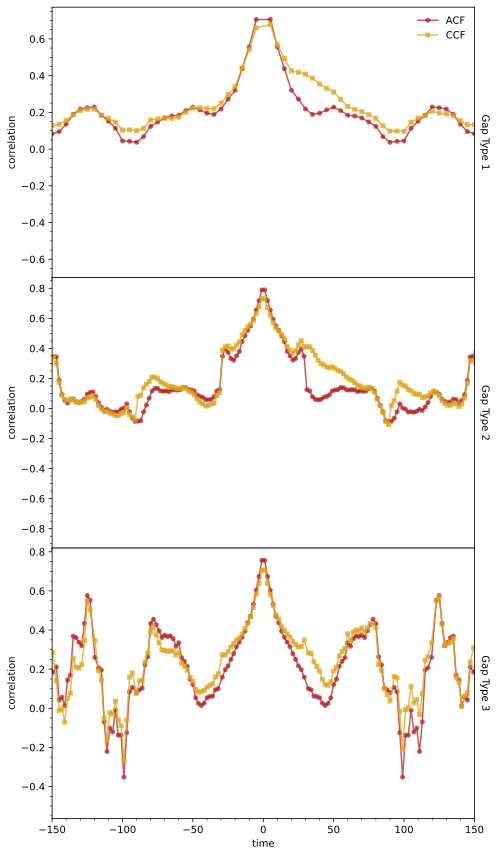

In [11]:
acf_44_gap_1 = photRM.add_inverted_acf(acf_44_gap_1)
acf_44_gap_2 = photRM.add_inverted_acf(acf_44_gap_2)
acf_44_gap_3 = photRM.add_inverted_acf(acf_44_gap_3)

acf_44_gap_1 = acf_44_gap_1.drop_duplicates(subset=['tau']).sort_values('tau')
acf_44_gap_2 = acf_44_gap_2.drop_duplicates(subset=['tau']).sort_values('tau')
acf_44_gap_3 = acf_44_gap_3.drop_duplicates(subset=['tau']).sort_values('tau')

acf_44_gap_1 = photRM.interp(ccf_44_gap_1, acf_44_gap_1)
acf_44_gap_2 = photRM.interp(ccf_44_gap_2, acf_44_gap_2)
acf_44_gap_3 = photRM.interp(ccf_44_gap_3, acf_44_gap_3)

fig, axs = plt.subplots(3, 1, figsize=[7, 12], sharex=True, layout='tight', gridspec_kw={'hspace': 0})

axs[0].plot(acf_44_gap_1['tau'], acf_44_gap_1['dcf'], 'o-', c='firebrick', mec='none', ms=5, alpha=0.75, label='ACF')
axs[0].plot(ccf_44_gap_1['tau'], ccf_44_gap_1['dcf'], 's-', c='goldenrod', mec='none', ms=5, alpha=0.75, label='CCF')
axs[0].annotate('Gap Type 1', xy=(1.025, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[0].set_ylabel('correlation')
axs[0].set_xlim(-150, 150)
axs[0].legend()

axs[1].plot(acf_44_gap_2['tau'], acf_44_gap_2['dcf'], 'o-', c='firebrick', mec='none', ms=5, alpha=0.75)
axs[1].plot(ccf_44_gap_2['tau'], ccf_44_gap_2['dcf'], 's-', c='goldenrod', mec='none', ms=5, alpha=0.75)
axs[1].annotate('Gap Type 2', xy=(1.025, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[1].set_ylabel('correlation')
axs[1].set_xlim(-150, 150)

axs[2].plot(acf_44_gap_3['tau'], acf_44_gap_3['dcf'], 'o-', c='firebrick', mec='none', ms=5, alpha=0.75)
axs[2].plot(ccf_44_gap_3['tau'], ccf_44_gap_3['dcf'], 's-', c='goldenrod', mec='none', ms=5, alpha=0.75)
axs[2].annotate('Gap Type 3', xy=(1.025, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[2].set_ylabel('correlation')
axs[2].set_xlim(-150, 150)
axs[2].set_xlabel('time')

plt.show()
plt.close()

Peak candidates (x-axis vals):  [35. 90.]
Max. peak:  35.0
Peak candidates (x-axis vals):  [23. 35. 83. 87.]
Max. peak:  35.0
Peak candidates (x-axis vals):  [29.08955224 34.         64.         70.         86.        ]
Max. peak:  29.08955223880597


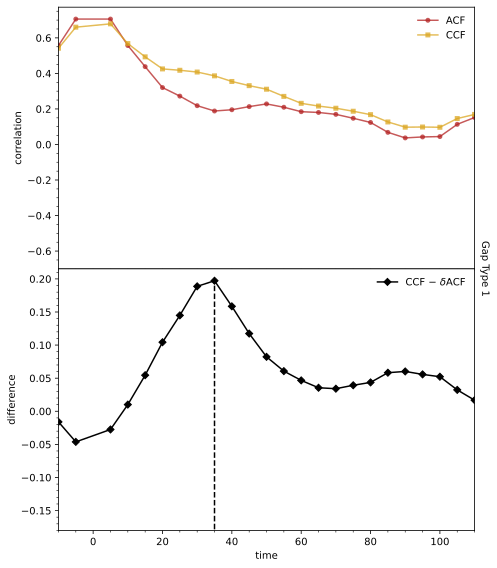

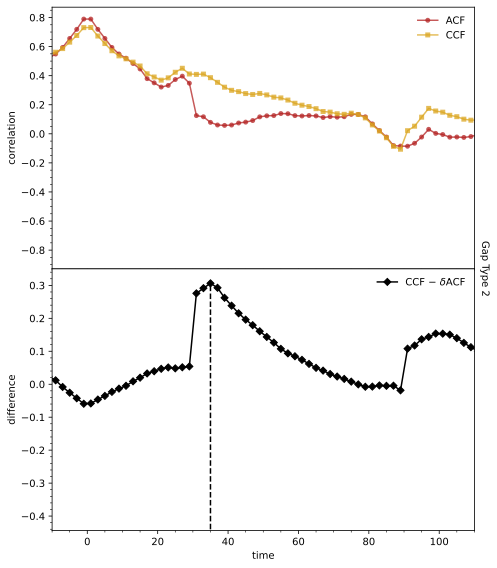

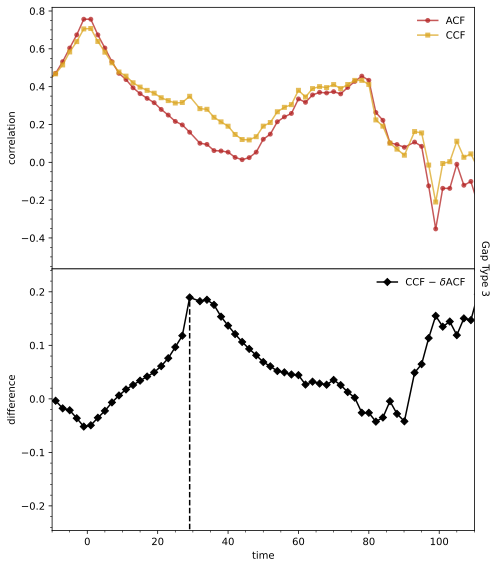

In [12]:
diff_44_gap_1 = photRM.delta_ccf(acf_44_gap_1, ccf_44_gap_1)
diff_44_gap_2 = photRM.delta_ccf(acf_44_gap_2, ccf_44_gap_2)
diff_44_gap_3 = photRM.delta_ccf(acf_44_gap_3, ccf_44_gap_3)

tau_44_gap_1, peaks_x_44_gap_1, peaks_y_44_gap_1 = photRM.peak_finder(diff_44_gap_1.dcf.values,
                                                                      diff_44_gap_1.tau.values,
                                                                      (0,100))
tau_44_gap_2, peaks_x_44_gap_2, peaks_y_44_gap_2 = photRM.peak_finder(diff_44_gap_2.dcf.values,
                                                                      diff_44_gap_2.tau.values,
                                                                      (0,100))
tau_44_gap_3, peaks_x_44_gap_3, peaks_y_44_gap_3 = photRM.peak_finder(diff_44_gap_3.dcf.values,
                                                                      diff_44_gap_3.tau.values,
                                                                      (0,100))

fig, axs = plt.subplots(2, 1, figsize=[7, 8], sharex=True, layout='tight', gridspec_kw={'hspace': 0})

axs[0].plot(acf_44_gap_1['tau'], acf_44_gap_1['dcf'], 'o-', c='firebrick', mec='none', ms=5, alpha=0.75, label='ACF')
axs[0].plot(ccf_44_gap_1['tau'], ccf_44_gap_1['dcf'], 's-', c='goldenrod', mec='none', ms=5, alpha=0.75, label='CCF')
axs[0].annotate('Gap Type 1', xy=(1.025, 0), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[0].set_ylabel('correlation')
axs[0].set_xlim(-10, 110)
axs[0].legend()

axs[1].plot(diff_44_gap_1['tau'], diff_44_gap_1['dcf'], 'D-k', ms=5, label=r'CCF $-$ $\delta$ACF')
axs[1].set_ylabel('difference')
axs[1].set_xlabel('time')
axs[1].set_ylim(axs[1].set_ylim())
axs[1].vlines(peaks_x_44_gap_1[np.argmax(peaks_y_44_gap_1)], -100,
              peaks_y_44_gap_1[np.argmax(peaks_y_44_gap_1)], ls='--', color='k')
axs[1].set_xlim(-10, 110)
axs[1].legend()

fig, axs = plt.subplots(2, 1, figsize=[7, 8], sharex=True, layout='tight', gridspec_kw={'hspace': 0})

axs[0].plot(acf_44_gap_2['tau'], acf_44_gap_2['dcf'], 'o-', c='firebrick', mec='none', ms=5, alpha=0.75, label='ACF')
axs[0].plot(ccf_44_gap_2['tau'], ccf_44_gap_2['dcf'], 's-', c='goldenrod', mec='none', ms=5, alpha=0.75, label='CCF')
axs[0].annotate('Gap Type 2', xy=(1.025, 0), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[0].set_ylabel('correlation')
axs[0].set_xlim(-10, 110)
axs[0].legend()

axs[1].plot(diff_44_gap_2['tau'], diff_44_gap_2['dcf'], 'D-k', ms=5, label=r'CCF $-$ $\delta$ACF')
axs[1].set_ylabel('difference')
axs[1].set_xlabel('time')
axs[1].set_ylim(axs[1].set_ylim())
axs[1].vlines(peaks_x_44_gap_2[np.argmax(peaks_y_44_gap_2)], -100,
              peaks_y_44_gap_2[np.argmax(peaks_y_44_gap_2)], ls='--', color='k')
axs[1].set_xlim(-10, 110)
axs[1].legend()

fig, axs = plt.subplots(2, 1, figsize=[7, 8], sharex=True, layout='tight', gridspec_kw={'hspace': 0})

axs[0].plot(acf_44_gap_3['tau'], acf_44_gap_3['dcf'], 'o-', c='firebrick', mec='none', ms=5, alpha=0.75, label='ACF')
axs[0].plot(ccf_44_gap_3['tau'], ccf_44_gap_3['dcf'], 's-', c='goldenrod', mec='none', ms=5, alpha=0.75, label='CCF')
axs[0].annotate('Gap Type 3', xy=(1.025, 0), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[0].set_ylabel('correlation')
axs[0].set_xlim(-10, 110)
axs[0].legend()

axs[1].plot(diff_44_gap_3['tau'], diff_44_gap_3['dcf'], 'D-k', ms=5, label=r'CCF $-$ $\delta$ACF')
axs[1].set_ylabel('difference')
axs[1].set_xlabel('time')
axs[1].set_ylim(axs[1].set_ylim())
axs[1].vlines(peaks_x_44_gap_3[np.argmax(peaks_y_44_gap_3)], -100,
              peaks_y_44_gap_3[np.argmax(peaks_y_44_gap_3)], ls='--', color='k')
axs[1].set_xlim(-10, 110)
axs[1].legend()

plt.show()
plt.close()

#### Conclusion:

- regular gap cadence produces more reliable results than noisy alternatives

## 2. Real Observations

### d)

#### Task:

- retrieve lightcurves used in [J/ApJ/756/73](https://ui.adsabs.harvard.edu/abs/2012ApJ...756...73E/abstract)
- choose filters with continuum and with broad emission lines
- format and plot the obtained data
- perform photometric reverberation mapping on first segment
- compare results and discuss spectroscopic reverberation mapping differences

#### Result:

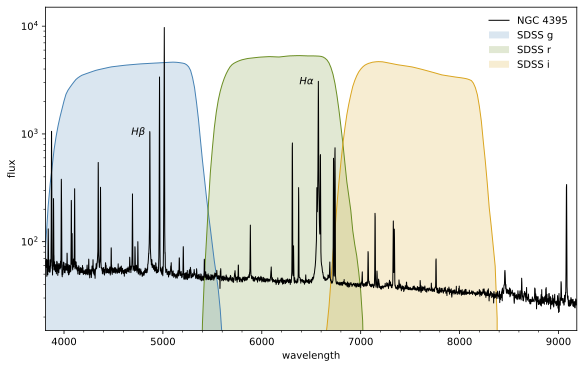

In [13]:
pos = coords.SkyCoord.from_name('NGC 4395', frame='icrs')
xid = SDSS.query_region(pos, spectro=True, radius=5*u.arcsec)
sp = SDSS.get_spectra(matches=xid)

flux = sp[0][1].data['flux']

loglam = sp[0][1].data['loglam']
lam = 10**loglam

scale = np.max(flux)

fig, ax = plt.subplots(1, 1, figsize=[8, 5])

ax.plot(lam, flux, color='black', lw=1, zorder=100, label='NGC 4395')

f_g = speclite.filters.load_filter('sdss2010noatm-g')
ax.fill_between(f_g.wavelength, 0, f_g.response * scale, alpha=0.2, fc='steelblue', ec='none', label='SDSS g')
ax.plot(f_g.wavelength, f_g.response * scale, c='steelblue', lw=1)

f_r = speclite.filters.load_filter('sdss2010noatm-r')
ax.fill_between(f_r.wavelength, 0, f_r.response * scale, alpha=0.2, fc='olivedrab', ec='none', label='SDSS r')
ax.plot(f_r.wavelength, f_r.response * scale, c='olivedrab', lw=1)

f_i = speclite.filters.load_filter('sdss2010noatm-i')
ax.fill_between(f_i.wavelength, 0, f_i.response * scale, alpha=0.2, fc='goldenrod', ec='none', label='SDSS i')
ax.plot(f_i.wavelength, f_i.response * scale, c='goldenrod', lw=1)

ax.text(4680, 980, r'$H\beta$')
ax.text(6380, 2890, r'$H\alpha$')

ax.set_xlabel('wavelength')
ax.set_ylabel('flux')

ax.set_xlim(min(lam), max(lam))
ax.set_ylim(1.5e1, 1.5e4)

ax.set_yscale('log')

ax.legend()

plt.show()
plt.close()

In [14]:
print(lc_proc.__doc__)


    Process a list of light curves from Edri et al. (2012). Each light curve 
    is stored as a pandas dataframe.
    
    Parameters:
    -----------
    lcs: list (elements assumed to be pd.DataFrame objects)
        A list of light curves. Each light curve is a pd.DataFrame with columns:
        MJD, mag, mag_err
    filters: str
        Corresponding filter names for light curves (possible vals: 'r', 'g', 'i')
    time: str
        Time unit to convert into. Default is 'hours'.
        
    Returns:
    --------
    lcs: list
        A list of input light curves with added columns: time_hours, flux, 
        flux_err, norm_flux, norm_flux_err

    


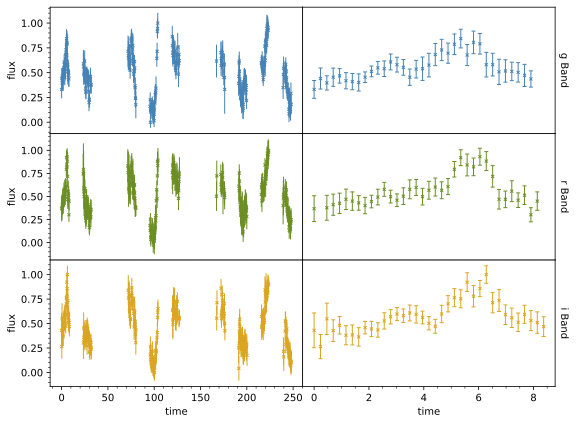

In [15]:
cat_id = 'J/ApJ/756/73'

v = Vizier(columns=['*'], catalog=cat_id)
v.ROW_LIMIT = -1

tabs = v.get_catalogs(cat_id)
lc_tab = tabs[0]

lc_tab_g = pd.DataFrame()
lc_tab_g['MJD'] = lc_tab['JD'][lc_tab['Filt'] == 'g']
lc_tab_g['mag'] = lc_tab['mag'][lc_tab['Filt'] == 'g']
lc_tab_g['mag_err'] = lc_tab['e_mag'][lc_tab['Filt'] == 'g']

lc_tab_r = pd.DataFrame()
lc_tab_r['MJD'] = lc_tab['JD'][lc_tab['Filt'] == 'r']
lc_tab_r['mag'] = lc_tab['mag'][lc_tab['Filt'] == 'r']
lc_tab_r['mag_err'] = lc_tab['e_mag'][lc_tab['Filt'] == 'r']

lc_tab_i = pd.DataFrame()
lc_tab_i['MJD'] = lc_tab['JD'][lc_tab['Filt'] == 'i']
lc_tab_i['mag'] = lc_tab['mag'][lc_tab['Filt'] == 'i']
lc_tab_i['mag_err'] = lc_tab['e_mag'][lc_tab['Filt'] == 'i']

lc_list = lc_proc(list([lc_tab_g, lc_tab_r, lc_tab_i]), ['g', 'r', 'i'])

g_t = lc_list[0]['time_hours'][:]
g_flux = lc_list[0]['norm_flux'][:]
g_flux_err = lc_list[0]['norm_flux_err'][:]

r_t = lc_list[1]['time_hours'][:]
r_flux = lc_list[1]['norm_flux'][:]
r_flux_err = lc_list[1]['norm_flux_err'][:]

i_t = lc_list[2]['time_hours'][:]
i_flux = lc_list[2]['norm_flux'][:]
i_flux_err = lc_list[2]['norm_flux_err'][:]


fig, axs = plt.subplots(3, 2, figsize=[8, 6], layout='tight', gridspec_kw={'hspace': 0, 'wspace': 0})

axs[0, 0].errorbar(g_t, g_flux, yerr=g_flux_err, fmt='x', ms=3, lw=1, color='steelblue')
ylim_g = axs[0, 0].set_ylim()
xlim = axs[0, 0].set_xlim()
axs[0, 0].set_ylabel('flux')

axs[1, 0].errorbar(r_t, r_flux, yerr=r_flux_err, fmt='x', ms=3, lw=1, color='olivedrab')
ylim_r = axs[1, 0].set_ylim()
axs[1, 0].set_xlim(xlim)
axs[1, 0].set_ylabel('flux')

axs[2, 0].errorbar(i_t, i_flux, yerr=i_flux_err, fmt='x', ms=3, lw=1, color='goldenrod')
ylim_i = axs[2, 0].set_ylim()
axs[2, 0].set_xlabel('time')
axs[2, 0].set_xlim(xlim)
axs[2, 0].set_ylabel('flux')

g_t, g_flux, g_flux_err = g_t[:35], g_flux[:35], g_flux_err[:35]
r_t, r_flux, r_flux_err = r_t[:35], r_flux[:35], r_flux_err[:35]
i_t, i_flux, i_flux_err = i_t[:37], i_flux[:37], i_flux_err[:37]

axs[0, 1].errorbar(g_t, g_flux, yerr=g_flux_err, fmt='x', ms=3, capsize=2, lw=1, color='steelblue')
axs[0, 1].set_ylim(ylim_g)
axs[0, 1].set_yticks([])
axs[0, 1].annotate('g Band', xy=(1.035, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')

axs[1, 1].errorbar(r_t, r_flux, yerr=r_flux_err, fmt='x', ms=3, capsize=2, lw=1, color='olivedrab')
axs[1, 1].set_ylim(ylim_r)
axs[1, 1].set_yticks([])
axs[1, 1].annotate('r Band', xy=(1.035, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')

axs[2, 1].errorbar(i_t, i_flux, yerr=i_flux_err, fmt='x', ms=3, capsize=2, lw=1, color='goldenrod')
axs[2, 1].set_ylim(ylim_i)
xlim = axs[2, 1].set_xlim()
axs[2, 1].set_yticks([])
axs[2, 1].set_xlabel('time')
axs[2, 1].annotate('i Band', xy=(1.035, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')

axs[0, 1].set_xlim(xlim)
axs[1, 1].set_xlim(xlim)

plt.show()
plt.close()

with open('data/g_band.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(g_t, g_flux, g_flux_err):
        f.write(templ.format(*line))
with open('data/r_band.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(r_t, r_flux, r_flux_err):
        f.write(templ.format(*line))
with open('data/i_band.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(i_t, i_flux, i_flux_err):
        f.write(templ.format(*line))

In [16]:
par_dict = {
    'autocf': True,
    'prefix': 'acf_ha_hb',
    'uniform_sampling': False,
    'omit_zero_lags': True,
    'minpts': 0,
    'num_MC': 100,
    'lc1_name': 'i_band.txt'
}

acf_ha_hb = pyzdcf('./data/', './results/', intr=False, parameters=par_dict, sep=' ', sparse='auto')

par_dict = {
    'autocf': False,
    'prefix': 'ccf_ha',
    'uniform_sampling': False,
    'omit_zero_lags': True,
    'minpts': 0,
    'num_MC': 100,
    'lc1_name': 'i_band.txt',
    'lc2_name': 'r_band.txt',
}

ccf_ha = pyzdcf('./data/', './results/', intr=False, parameters=par_dict, sep=' ', sparse='auto')

par_dict = {
    'autocf': False,
    'prefix': 'ccf_hb',
    'uniform_sampling': False,
    'omit_zero_lags': True,
    'minpts': 0,
    'num_MC': 100,
    'lc1_name': 'i_band.txt',
    'lc2_name': 'g_band.txt',
}

ccf_hb = pyzdcf('./data/', './results/', intr=False, parameters=par_dict, sep=' ', sparse='auto')


pyZDCF begins:

pyZDCF PARAMETERS:

Autocorrelation?   True
Uniform sampling?  False
Omit zero lags?    True
Minimal # in bin:  11
# of Monte Carlo:  100
Monte Carlo seed:  123456

Binning with minimum of 11 points per bin and resolution of 0.001

27 bins actually used, 45.0 inter-dependent pairs discarded.


acf_ha_hb.dcf written...

pyZDCF ended.


pyZDCF begins:

pyZDCF PARAMETERS:

Autocorrelation?   False
Uniform sampling?  False
Omit zero lags?    True
Minimal # in bin:  11
# of Monte Carlo:  100
Monte Carlo seed:  123456

Binning with minimum of 11 points per bin and resolution of 0.001

54 bins actually used, 94 inter-dependent pairs discarded.


ccf_ha.dcf written...

pyZDCF ended.


pyZDCF begins:

pyZDCF PARAMETERS:

Autocorrelation?   False
Uniform sampling?  False
Omit zero lags?    True
Minimal # in bin:  11
# of Monte Carlo:  100
Monte Carlo seed:  123456

Binning with minimum of 11 points per bin and resolution of 0.001

54 bins actually used, 96 inter-dependent pairs 

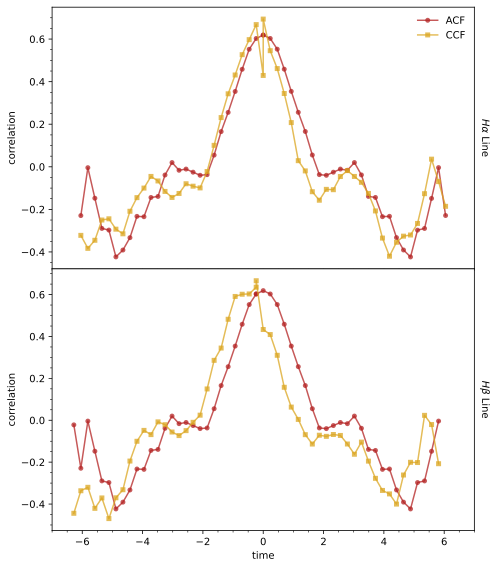

In [17]:
acf_ha_hb = photRM.add_inverted_acf(acf_ha_hb)

acf_ha_hb = acf_ha_hb.drop_duplicates(subset=['tau']).sort_values('tau')

acf_ha = photRM.interp(ccf_ha, acf_ha_hb)
acf_hb = photRM.interp(ccf_hb, acf_ha_hb)

fig, axs = plt.subplots(2, 1, figsize=[7, 8], sharex=True, layout='tight', gridspec_kw={'hspace': 0})

axs[0].plot(acf_ha['tau'], acf_ha['dcf'], 'o-', c='firebrick', mec='none', ms=5, alpha=0.75, label='ACF')
axs[0].plot(ccf_ha['tau'], ccf_ha['dcf'], 's-', c='goldenrod', mec='none', ms=5, alpha=0.75, label='CCF')
axs[0].annotate(r'$H\alpha$ Line', xy=(1.025, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[0].set_ylabel('correlation')
axs[0].set_xlim(-7, 7)
axs[0].legend()

axs[1].plot(acf_hb['tau'], acf_hb['dcf'], 'o-', c='firebrick', mec='none', ms=5, alpha=0.75)
axs[1].plot(ccf_hb['tau'], ccf_hb['dcf'], 's-', c='goldenrod', mec='none', ms=5, alpha=0.75)
axs[1].annotate(r'$H\beta$ Line', xy=(1.025, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[1].set_ylabel('correlation')
axs[1].set_xlim(-7, 7)
axs[1].set_xlabel('time')

plt.show()
plt.close()

Peak candidates (x-axis vals):  [2.09246224 2.79016002 3.48790856]
Max. peak:  3.4879085563478016
Peak candidates (x-axis vals):  [1.86028445 3.48837599 3.95354666]
Max. peak:  1.860284447669983


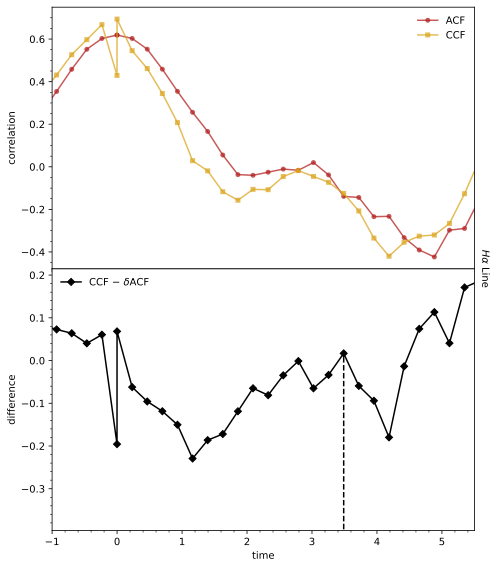

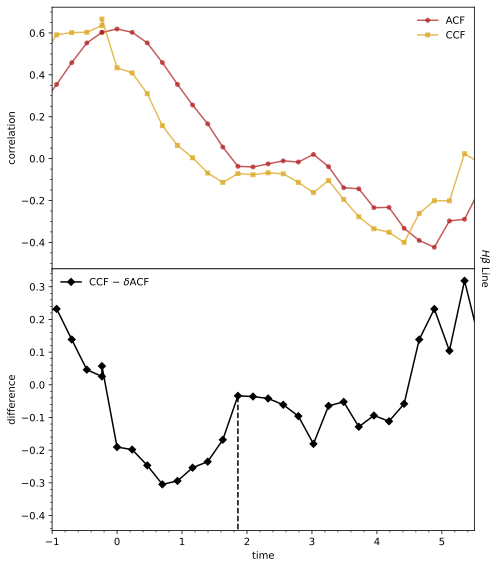

In [18]:
diff_ha = photRM.delta_ccf(acf_ha, ccf_ha)
diff_hb = photRM.delta_ccf(acf_hb, ccf_hb)

tau_ha, peaks_x_ha, peaks_y_ha = photRM.peak_finder(diff_ha.dcf.values, diff_ha.tau.values, (0,5))
tau_hb, peaks_x_hb, peaks_y_hb = photRM.peak_finder(diff_hb.dcf.values, diff_hb.tau.values, (0,5))

fig, axs = plt.subplots(2, 1, figsize=[7, 8], sharex=True, layout='tight', gridspec_kw={'hspace': 0})

axs[0].plot(acf_ha['tau'], acf_ha['dcf'], 'o-', c='firebrick', mec='none', ms=5, alpha=0.75, label='ACF')
axs[0].plot(ccf_ha['tau'], ccf_ha['dcf'], 's-', c='goldenrod', mec='none', ms=5, alpha=0.75, label='CCF')
axs[0].annotate(r'$H\alpha$ Line', xy=(1.025, 0), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[0].set_ylabel('correlation')
axs[0].set_xlim(-0.5, 5.5)
axs[0].legend()

axs[1].plot(diff_ha['tau'], diff_ha['dcf'], 'D-k', ms=5, label=r'CCF $-$ $\delta$ACF')
axs[1].set_ylabel('difference')
axs[1].set_xlabel('time')
axs[1].set_ylim(axs[1].set_ylim())
axs[1].vlines(peaks_x_ha[np.argmax(peaks_y_ha)], -100, peaks_y_ha[np.argmax(peaks_y_ha)], ls='--', color='k')
axs[1].set_xlim(-1, 5.5)
axs[1].legend()

plt.show()
plt.close()

fig, axs = plt.subplots(2, 1, figsize=[7, 8], sharex=True, layout='tight', gridspec_kw={'hspace': 0})

axs[0].plot(acf_hb['tau'], acf_hb['dcf'], 'o-', c='firebrick', mec='none', ms=5, alpha=0.75, label='ACF')
axs[0].plot(ccf_hb['tau'], ccf_hb['dcf'], 's-', c='goldenrod', mec='none', ms=5, alpha=0.75, label='CCF')
axs[0].annotate(r'$H\beta$ Line', xy=(1.025, 0), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[0].set_ylabel('correlation')
axs[0].set_xlim(-1, 5.5)
axs[0].legend()

axs[1].plot(diff_hb['tau'], diff_hb['dcf'], 'D-k', ms=5, label=r'CCF $-$ $\delta$ACF')
axs[1].set_ylabel('difference')
axs[1].set_xlabel('time')
axs[1].set_ylim(axs[1].set_ylim())
axs[1].vlines(peaks_x_hb[np.argmax(peaks_y_hb)], -100, peaks_y_hb[np.argmax(peaks_y_hb)], ls='--', color='k')
axs[1].set_xlim(-1, 5.5)
axs[1].legend()

plt.show()
plt.close()

#### Comparison:

- similar to [J/ApJ/756/73](https://ui.adsabs.harvard.edu/abs/2012ApJ...756...73E/abstract)
- *Hα ~ 3.5h*
- *Hβ ~ 1.9h*
- sensible since higher ionization regions are found closer to central driver

#### Discussion:

- resolved spectroscopic reverberation mapping
  - allows for highly accurate flux measurements of individual emission lines
  - provides high sensitivity but is extremely time consuming for observations
  - limited sample size with only about tens of objects mapped over two decades due to resource intensity
  - requires long integration times to achieve sufficient signal to noise ratios
- narrow band photometric reverberation mapping
  - serves as a specialized alternative to spectroscopy
  - requires specific filters that must be precisely matched to the object redshift and emission lines
  - less flexible than broad band methods because filters are tuned to specific targets
- broad band photometric reverberation mapping
  - offers a significantly more efficient and quicker approach compared to spectroscopy
  - utilizes standard broad band images
  - less sensitive but highly scalable
  - ideal for upcoming large scale surveys to estimate masses for millions of quasars
  - especially effective for objects where spectroscopic lag times are too short for practical integration
  - relies on the statistical response of lines within a wider filter rather than isolating a single line profile